C:\Users\mapol\AppData\Local\Temp\ipykernel_21316\3233758826.py:69: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  res = res.replace(["n/e", "-"], np.nan)
C:\Users\mapol\AppData\Local\Temp\ipykernel_21316\3233758826.py:149: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Market["wind_error_lag"] = Market["wind_error_lag"].fillna(method = "ffill")


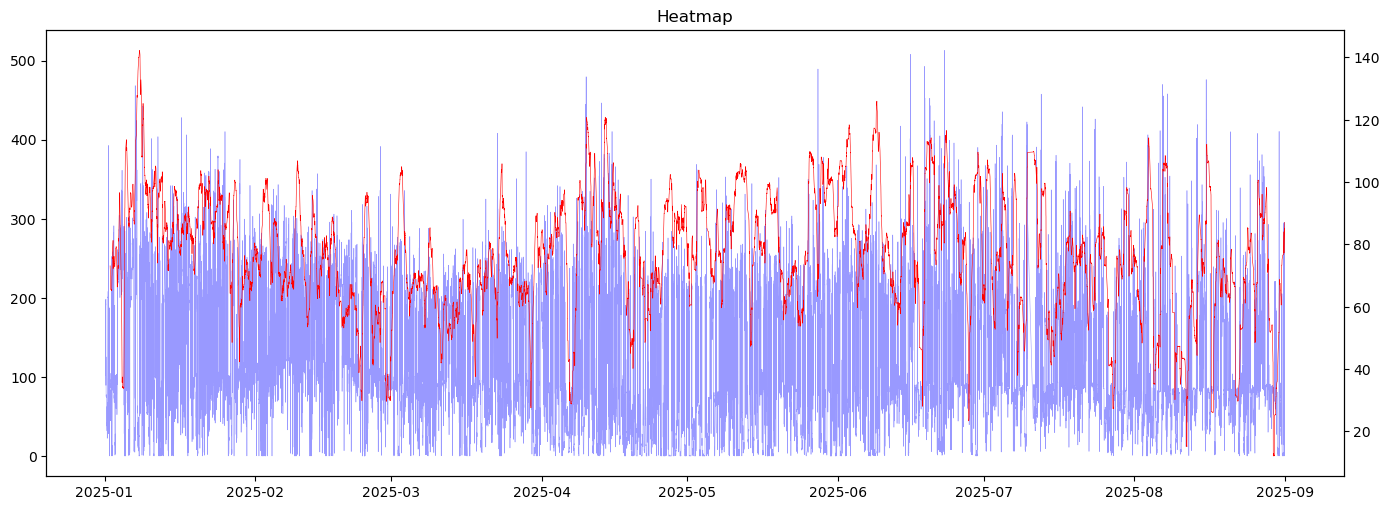

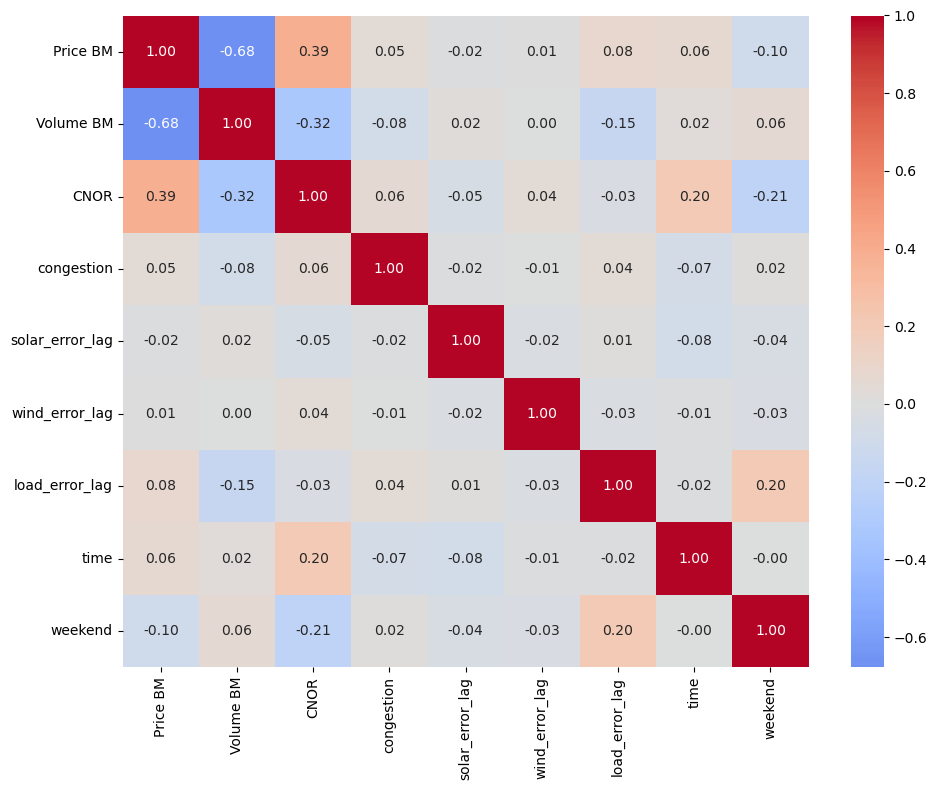

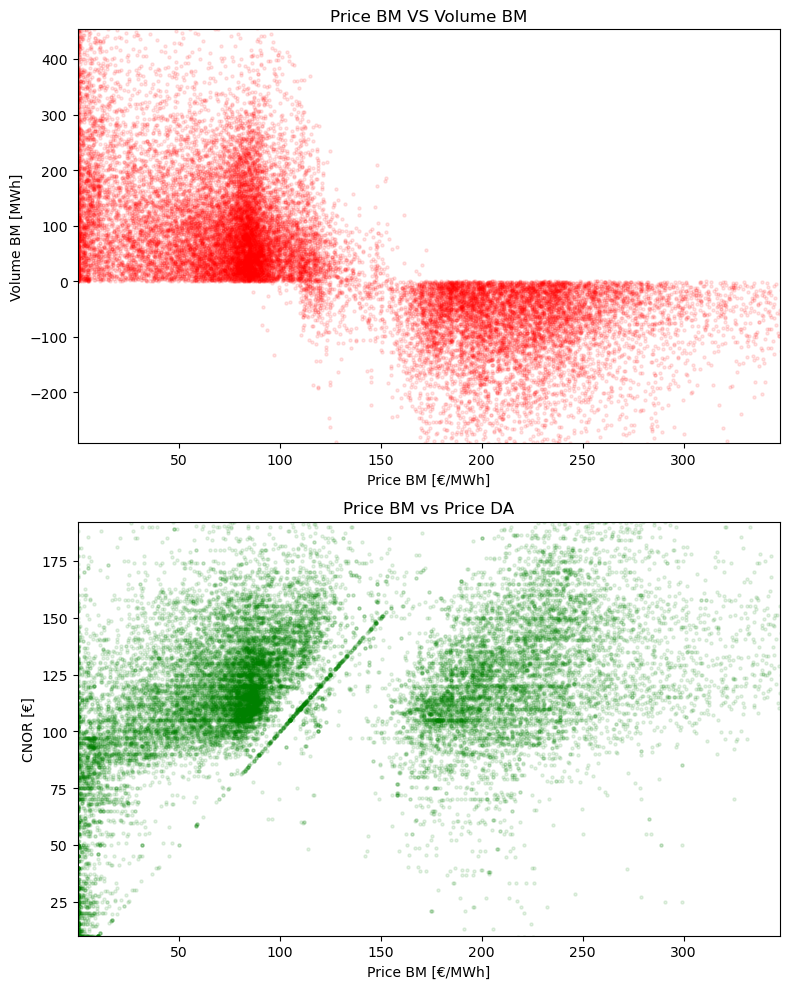

In [48]:
import pandas as pd
import glob
import numpy as np


#========== Data Cleaning ==========#


# 1) DAY AHEAD PRICES .xml 

files = glob.glob("MGP january june/*.xml")
frames = []

for i in files:
    df = pd.read_xml(i)
    prezzi = df[["Data", "Ora", "PUN", "CNOR"]].copy()
    prezzi["Data"] = pd.to_datetime(prezzi["Data"], format="%Y%m%d")
    prezzi["PUN"] = pd.to_numeric(prezzi["PUN"].str.replace(",","."), errors = "coerce") 
    prezzi["CNOR"] = pd.to_numeric(prezzi["CNOR"].str.replace(",","."), errors = "coerce") 
    frames.append(prezzi)

prezzi_MGP = pd.concat(frames).sort_values(["Data", "Ora"]).reset_index(drop=True)
prezzi_MGP = prezzi_MGP.dropna()

#prezzi_MGP.isnull().sum()         # 181 null elements: one for each file, it is just the NaN of the first quarter
#prezzi.plot(x = "Ora", y = "PUN") # daily distribution I expected (peaks)
#prezzi_MGP["PUN"].describe()      # mean is 119, max is 289, min is 0. A too high max, if compared to the mean, would have been in need of explanation
                                   # no negative prices

# for July and August, the GME (gestore mercati energetici) website changed to excel files (.xlsx)

luglio = pd.read_excel("MGP july august/july.xlsx")
july = pd.DataFrame()
july["Data"] = pd.to_datetime(luglio["Data"], format = "%d/%m/%Y")
july["Ora"] = luglio["Ora"]
july["CNOR"] = pd.to_numeric(luglio["Centro Nord"].str.replace(",","."), errors = "coerce")
july["PUN"] = pd.to_numeric(luglio["Italia"].str.replace(",","."), errors = "coerce")

agosto = pd.read_excel("MGP july august/august.xlsx")
august = pd.DataFrame()
august["Data"] = pd.to_datetime(agosto["Data"], format = "%d/%m/%Y")
august["Ora"] = agosto["Ora"]
august["CNOR"] = pd.to_numeric(agosto["Centro Nord"].str.replace(",","."), errors = "coerce")
august["PUN"] = pd.to_numeric(agosto["Italia"].str.replace(",","."), errors = "coerce")


julyaugust = pd.concat([july, august]).sort_values(["Data", "Ora"]).reset_index(drop=True)
prices_DA = pd.concat([prezzi_MGP, julyaugust]).sort_values(["Data", "Ora"]).reset_index(drop=True)

# to omologate to the next dataframes
prices_DA["datetime"] = prices_DA["Data"] + pd.to_timedelta(prices_DA["Ora"] - 1, unit="h")
prices_DA = prices_DA.loc[prices_DA.index.repeat(4)].copy()
prices_DA["datetime"] = prices_DA["datetime"] + pd.to_timedelta([0, 15, 30, 45] * (len(prices_DA) // 4), unit="min")

# 2) LOAD FORECAST AND ACTUAL .csv

# load = pd.read_csv("LOAD/load_forecast_actual.csv", sep=";")
carico = pd.read_csv("LOAD/load_forecast_actual.csv", sep=";")
carico = carico.replace("-", np.nan)
load = pd.DataFrame()
load["load_forecast"] = pd.to_numeric(carico["Day-ahead Total Load Forecast [MW] - BZN|IT-North"].str.replace(",", "."))
load["load_actual"] = pd.to_numeric(carico["Actual Total Load [MW] - BZN|IT-North"].str.replace(",", "."))
load = load.dropna()
load["datetime"] = pd.to_datetime(carico["Time (CET/CEST)"].str.split(" - ").str[0],format="%d.%m.%Y %H:%M")

# 3) RES GENERATION FORECAST AND ACTUAL .csv

res = pd.read_csv("RES/generation_forecast_actual.csv", sep=";")
res = res.replace(["n/e", "-"], np.nan)

# res has no offshore data, no onshore current

res = res.rename(columns = {"Generation - Solar [MW] Day Ahead/ Italy (IT)" : "Solar Forecast"})
res = res.rename(columns = {"Generation - Solar [MW] Current / Italy (IT)" : "Solar Actual"})
res = res.rename(columns = {"Generation - Wind Onshore [MW] Day Ahead/ Italy (IT)" : "Wind Forecast"})
res = res.rename(columns = {"Generation - Wind Onshore [MW] Intraday / Italy (IT)" : "Wind Actual"})
res["datetime"] = pd.to_datetime(res["MTU (CET/CEST)"].str.split(" - ").str[0], format = "%d.%m.%Y %H:%M")

# by splitting res in wind + solar I saved 7 thousands lines of data of solar that were discarded by the "dropna" function applied on res

wind = res[["datetime", "Wind Forecast", "Wind Actual"]]
solar = res[["datetime", "Solar Forecast", "Solar Actual"]]
wind = wind.dropna().reset_index(drop = True)
solar = solar.dropna().reset_index(drop = True)

solar["Solar Forecast"] = solar["Solar Forecast"].astype(float)
wind["Wind Actual"] = wind["Wind Actual"].astype(float)
wind["Wind Forecast"] = wind["Wind Forecast"].astype(float)

# 4) VOLUMES AND PRICES OF THE BALANCING MARKET

links = glob.glob("MB/*.csv")
MB = []

for i in links:
    parts = pd.read_csv(i, sep=";")
    parts = parts.replace("SUD", np.nan)
    parts = parts.dropna()
    parts["datetime"] = pd.to_datetime(parts["Data Riferimento"], format = "%d/%m/%Y %H:%M")
    MB.append(parts)
    
prezzi_MB = pd.concat(MB).sort_values("datetime")
VeP_BM = pd.DataFrame()
VeP_BM["datetime"] = prezzi_MB["datetime"]
VeP_BM["Volume BM"] = pd.to_numeric(prezzi_MB["Sbil aggregato zonale [MWh]"].str.replace(",", "."))
VeP_BM["Sign"] = prezzi_MB["Segno aggregato zonale"]
VeP_BM["Price BM"] = pd.to_numeric(prezzi_MB["Prezzo di sbilanciamento"].str.replace(",", "."))


#========== Variables Preparation ==========#


prices_DA["congestion"] = 100*(prices_DA["PUN"] - prices_DA["CNOR"])/prices_DA["PUN"]
# prices_DA["congestion"].ne(0).sum()
# > 6000
# congestion is defined as the % difference in price between two macrozone
# in this case between PUN (uniqe national price) and CNOR (nord-centre macrozone)
# (congestions cause singularities in prices, I take as first approx the effect on the price itself)

# forecast errors will be the crucial variables to consider
# the lag is necessary to avoid leakage:
# 4 hours is the delay between the actual generation and its publication on ENTSOE
load["load_error"] = (load["load_actual"] - load["load_forecast"])
wind["wind error"] = (wind["Wind Actual"] - wind["Wind Forecast"])
solar["solar error"] = (solar["Solar Actual"] - solar["Solar Forecast"])

# creating the final dataframe
renewables = pd.merge(solar, wind, on = "datetime", how = "left")
prices = pd.merge(VeP_BM, prices_DA, on = "datetime", how = "left")
A = pd.merge(renewables, load, on = "datetime", how = "left")
Market = pd.merge(prices, A, on = "datetime", how = "left")
Market = Market.drop(columns = ["Data", "Ora"])
Market["wind_error_lag"] = Market["wind error"].shift(16)
Market["solar_error_lag"] = Market["solar error"].shift(16)
Market["load_error_lag"] = Market["load_error"].shift(16)
# Market starts from fourth hour of 1/1/25

# introducing autocorrelation (target lagged is used as a feature)
Market["Volume_BM_lag"] = Market["Volume BM"].shift(16)
Market["Price_BM_lag"] = Market["Price BM"].shift(16)

# introducing time related variables
Market ["time"] = Market["datetime"].dt.hour
Market ["weekend"] = Market["datetime"].dt.dayofweek >= 5

# NaN removal
# only wind source has significantly less data
# being probably not a crucial variable, I simply used a forward fill
Market["wind_error_lag"] = Market["wind_error_lag"].fillna(method = "ffill")
Market = Market.drop(columns = ["Wind Forecast", "Wind Actual", "wind error"])
Market = Market.dropna().reset_index(drop = True)
# < 0.8 % of data discarded


#========== Modelling ==========#


from sklearn.linear_model import LinearRegression

# Volume BM Linear Regression

train = Market[Market["datetime"] < "2025-07-1"]
test = Market[Market["datetime"] >= "2025-07-1"]

X_train = train[["CNOR", "congestion", "wind_error_lag", "solar_error_lag", "load_error_lag", "Volume_BM_lag", "time", "weekend"]]
Y_train = train["Volume BM"]
X_test = test[["CNOR", "congestion", "wind_error_lag", "solar_error_lag", "load_error_lag", "Volume_BM_lag", "time", "weekend"]]
Y_test = test["Volume BM"]

model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
rmse_mean = rmse / (Y_test.mean()) # = 2 (lol)
rmse_std = rmse / (Y_test.std()) # = 0.93 (ancora male)

# Prices BM Linear Regression

PX_train = train[["CNOR", "congestion", "wind_error_lag", "solar_error_lag", "load_error_lag", "Volume_BM_lag", "time", "weekend"]]
PY_train = train["Price BM"]
PX_test = test[["CNOR", "congestion", "wind_error_lag", "solar_error_lag", "load_error_lag", "Volume_BM_lag", "time", "weekend"]]
PY_test = test["Price BM"]

model = LinearRegression()
model.fit(PX_train, PY_train)
PY_pred = model.predict(PX_test)

Prmse = np.sqrt(mean_squared_error(PY_test, PY_pred))
Prmse_mean = Prmse / (PY_test.mean()) # 0.67
Prmse_std = Prmse / (PY_test.std()) # 0.94

# Y_test.describe()
# high volatility in balancing volumes, asymmetric distribution, number of outliers
# rmse both relative to mean and std deviation are too high
# linear regression cannot capture non linear dipendency between the variables
# non linear model and other variables can be used to improve the results

Volume BM RandomForest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
rmse_rf_std = rmse_rf / Y_test.std()
print(f"RMSE RF: {rmse_rf:.2f}")
print(f"RMSE/std: {rmse_rf_std:.3f}")

# Random Forest results are still poor (RMSE/std ≈ 0.956 for volume, similar for price)
# Main limitations: only 8 months of data (no annual seasonality captured),
# missing key features (gas price, thermoelectric generation),
# and no autoregressive terms (price/volume lags at t-1h, t-1d, t-1w)
# These improvements are left for future work with a longer time series


#========== Charts ==========#


import matplotlib.pyplot as plt

# plot 1: BM Price and Rolling Volatility over datetime

fig, ax = plt.subplots(figsize = (14,5))
ax.plot(Market["datetime"], Market["Price BM"], color = "blue", alpha = 0.4, linewidth = 0.4, label = "BM Price")

rolling_volatility = Market["Price BM"].rolling(96).std()
ax0 = ax.twinx()
ax0.plot(Market["datetime"], rolling_volatility, color = "red", alpha = 1, linewidth = 0.4, label = "BM Price")

plt.tight_layout()

# heatmap

import seaborn as sns

cols = ["Price BM", "Volume BM", "CNOR", "congestion", "solar_error_lag", "wind_error_lag", "load_error_lag", "time", "weekend"]
corr = Market[cols].corr()

fig, ax3 = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax3)

ax.set_title("Heatmap")

plt.tight_layout()

# scatter 1: solar error - BM Volume

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

ax1.scatter(Market["Price BM"], Market["Volume BM"], alpha=0.1, s=5, color="red")
ax1.set_xlim(Market["Price BM"].quantile(0.01), Market["Price BM"].quantile(0.99))
ax1.set_ylim(Market["Volume BM"].quantile(0.01), Market["Volume BM"].quantile(0.99))
ax1.set_xlabel("Price BM [€/MWh]")
ax1.set_ylabel("Volume BM [MWh]")
ax1.set_title("Price BM VS Volume BM")

# scatter 2: load error - BM Volume

ax2.scatter(Market["Price BM"], Market["CNOR"], alpha=0.1, s=5, color="green")
ax2.set_xlim(Market["Price BM"].quantile(0.01), Market["Price BM"].quantile(0.99))
ax2.set_ylim(Market["CNOR"].quantile(0.01), Market["CNOR"].quantile(0.99))
ax2.set_xlabel("Price BM [€/MWh]")
ax2.set_ylabel("CNOR [€]")
ax2.set_title("Price BM vs Price DA")

plt.tight_layout()

plt.show()


#========== Conclusions ==========#


# From the scatter plot of Price vs Volume, we can observe a strong negative correlation.
# Two distinct regimes are clearly visible — evaluating a single RMSE across the entire 
# dataset makes little sense, as it conflates two fundamentally different market states.
# A natural extension would be to build two separate models, one for each regime 
# (positive and negative volumes), with a preliminary regime classifier.

# Studying the boundary regime is crucial: the zone in which a single player 
# is no longer a price taker. This is exactly where theoretical mathematical models 
# break down, providing the core motivation for my thesis.
# A regime switch is a critical event: the received price can drop by two thirds 
# if the expected BM volume was -50 MWh while the actual turned out to be +50 MWh.

# Almost no linear correlation with RES errors — Random Forest and ARIMAX 
# will be needed to capture non-linear dependencies.
# Day-ahead price (CNOR) is a crucial proxy for fundamental market conditions.

# Note: this script represents a preliminary exploration of the dataset
# The complete work will include ARIMAX, Random Forest
# with rolling window validation, and a dedicated regime classification framework.
